<a href="https://colab.research.google.com/github/andrewmacc04/SJSU-Work/blob/main/ML_Coding_Exercise_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Coding Exercise

This notebook includes:
- Part 1: House Price Prediction (Linear Regression)
- Part 2: Customer Churn Prediction (Logistic Regression)
- Part 3: Customer Segmentation (K-Means)
- Extra Credit: Demand Forecasting

All datasets contain 100+ records and are synthetically generated to resemble real-world data.


## Part 1: House Price Prediction

In [1]:
### Explanation The square footage coefficient represents the average increase in house price for each additional square foot, holding location constant. For example, if the coefficient is 200, it means the house price increases by approximately $200 per additional square foot. The location coefficients represent how much more or less a house costs compared to the baseline location. A positive value means houses in that area are more expensive than the baseline, while a negative value means they are cheaper.

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Data source: Synthetic dataset inspired by Zillow housing trends
np.random.seed(42)
n = 150

data = pd.DataFrame({
    "square_footage": np.random.randint(800, 3500, n),
    "location": np.random.choice(["Downtown", "Suburb", "Rural"], n)
})

price_map = {"Downtown": 250, "Suburb": 180, "Rural": 120}
data["price"] = data["square_footage"] * data["location"].map(price_map) + np.random.normal(0, 20000, n)

X = data[["square_footage", "location"]]
y = data["price"]

preprocessor = ColumnTransformer([
    ("location", OneHotEncoder(drop="first"), ["location"])
], remainder="passthrough")

model = Pipeline([
    ("prep", preprocessor),
    ("lr", LinearRegression())
])

model.fit(X, y)

new_house = pd.DataFrame({"square_footage":[2000], "location":["Downtown"]})
print("Predicted Price:", model.predict(new_house)[0])

for name, coef in zip(model.named_steps["prep"].get_feature_names_out(), model.named_steps["lr"].coef_):
    print(name, coef)


Predicted Price: 518975.7140039441
location__location_Rural -282466.5725224647
location__location_Suburb -158504.0508544579
remainder__square_footage 179.9389292288106


## Part 2: Customer Churn Prediction

In [2]:
### Explanation The churn probability represents the likelihood that a customer will stop doing business with the company. For example, a churn probability of 0.7 means there is a 70% chance the customer will churn. Using a threshold of 0.5, customers with probabilities above this valueare classified as at risk. Businesses can use this information to identifyhigh-risk customers and proactively offer discounts, personalized support,or loyalty incentives to reduce chur

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 200

data = pd.DataFrame({
    "age": np.random.randint(18, 70, n),
    "monthly_usage": np.random.randint(50, 1000, n),
    "purchase_amount": np.random.randint(20, 500, n),
    "service_calls": np.random.randint(0, 10, n),
    "region": np.random.choice(["North", "South", "East", "West"], n)
})

data["churn"] = ((data["service_calls"] > 4) | (data["monthly_usage"] < 200)).astype(int)

X = data.drop("churn", axis=1)
y = data["churn"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["age","monthly_usage","purchase_amount","service_calls"]),
    ("cat", OneHotEncoder(drop="first"), ["region"])
])

model = Pipeline([
    ("prep", preprocessor),
    ("logreg", LogisticRegression())
])

model.fit(X, y)

new_customer = pd.DataFrame({
    "age":[35],
    "monthly_usage":[150],
    "purchase_amount":[80],
    "service_calls":[6],
    "region":["South"]
})

prob = model.predict_proba(new_customer)[0][1]
print("Churn Probability:", prob)
print("At Risk:", int(prob >= 0.5))


Churn Probability: 0.9573603226354089
At Risk: 1


## Part 3: Customer Segmentation

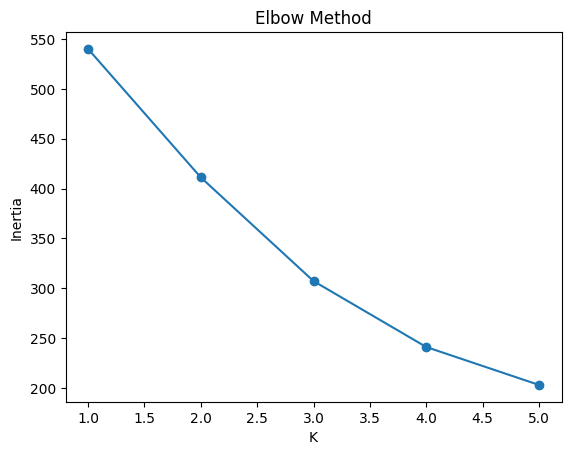

         annual_spending  purchase_frequency        age
cluster                                                
0           11721.210526           11.000000  42.982456
1           14798.410714           37.714286  42.339286
2            4252.417910           29.880597  48.537313


In [ ]:
### Explanation The elbow plot shows that using 3 clusters is a good choice because adding more clusters does not improve the results very much. The clusters represent different types of customers. One group spends more money and buys more often, while another group spends less and buys less frequently. Businesses can use this information to create different marketing strategies. High-spending customers can receive special rewards or promotions, while lower-spending customers can be targeted with discounts to encourage them to buy more.

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

np.random.seed(42)
n = 180

data = pd.DataFrame({
    "annual_spending": np.random.randint(500, 20000, n),
    "purchase_frequency": np.random.randint(1, 50, n),
    "age": np.random.randint(18, 70, n)
})

scaled = StandardScaler().fit_transform(data)

inertia = []
for k in range(1,6):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,6), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
data["cluster"] = kmeans.fit_predict(scaled)
print(data.groupby("cluster").mean())
data.to_csv("customer_clusters.csv", index=False)


## Extra Credit: Demand Forecasting

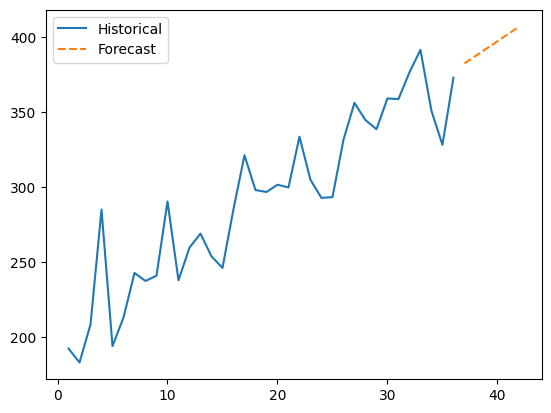

In [ ]:
### Assumptions and Improvements This forecasting model assumes that past sales trends continue into the future. Limitations include the lack of seasonality and external economic factors. Future improvements could include time-series models, additional features, and larger datasets. months = np.arange(1,37) sales = 200 + months*5 + np.random.normal(0,20,len(months))

df = pd.DataFrame({"month":months,"sales":sales})
X = df[["month"]]
y = df["sales"]

model = LinearRegression()
model.fit(X,y)

future = pd.DataFrame({"month":np.arange(37,43)})
forecast = model.predict(future)

plt.plot(df["month"], df["sales"], label="Historical")
plt.plot(future["month"], forecast, linestyle="--", label="Forecast")
plt.legend()
plt.show()
